# Exercises XP Gold - K-means from scratch

## What you will create
- A K-means implementation in pure NumPy.
- Scatter plots of clusters and centroid convergence.
- A report with cluster assignments per point.
- A random centroid initializer to study initialization impact.

## What you will learn
- Euclidean distance and closest-centroid assignment.
- How centroid updates reduce within-cluster variance.
- Why initialization matters and how to evaluate runs.


## Task 1 - Load and visualize the dataset
Dataset: `ex7data2.mat` contains an array `X` of shape (m, 2).

- Load with `scipy.io.loadmat`
- Inspect shape and preview first rows
- Scatter plot of points

--2026-06-11 00:12:11--  https://github.com/krasserm/machine-learning-notebooks/raw/master/data/ml-ex7/ex7data2.mat
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/krasserm/machine-learning-notebooks/master/data/ml-ex7/ex7data2.mat [following]
--2026-06-11 00:12:11--  https://raw.githubusercontent.com/krasserm/machine-learning-notebooks/master/data/ml-ex7/ex7data2.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4784 (4.7K) [application/octet-stream]
Saving to: ‘ex7data2.mat’

ex7data2.mat        100%[===================>]   4.67K  --.-KB/s    in 0s      

2026-06-11 00:12:11 (53.6 MB/s) - ‘e

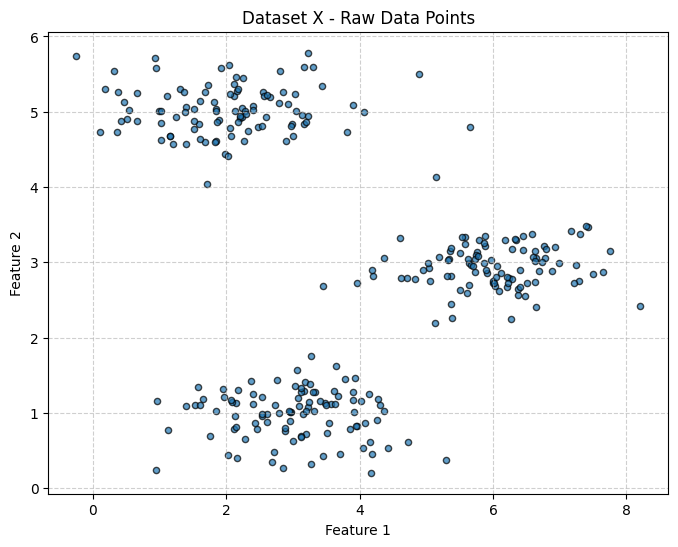

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Download the dataset if it's not already present
!wget -nc https://github.com/krasserm/machine-learning-notebooks/raw/master/data/ml-ex7/ex7data2.mat

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)
# TODO: set X to the numpy array of points
X = data['X']
print('Shape of X:', X.shape)
# TODO: preview first 5 rows
print('First 5 rows of X:\n', X[:5])

# TODO: scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, edgecolors='k', alpha=0.7)
plt.title('Dataset X - Raw Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Task 2 - Finding closest centroids
Implement `find_closest_centroids(X, centroids)`.

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances

Test with initial centroids = `np.array([[3, 3], [6, 2], [8, 5]])` and print the first three indices.

In [3]:
# TODO: implement
def find_closest_centroids(X, centroids):
    """Return idx of shape (m,) with index of closest centroid for each point."""
    # Get the number of training examples and number of centroids
    m = X.shape[0]
    K = centroids.shape[0]

    # Initialize idx as a 1D array of zeros
    idx = np.zeros(m, dtype=int)

    # For each example in X, find the closest centroid
    for i in range(m):
        # Compute distances of the current example to all centroids
        # Using broadcasting: (1, n) - (K, n) -> (K, n)
        # Then sum of squares over axis 1 to get squared Euclidean distances: (K,)
        distances = np.sum((X[i, :] - centroids)**2, axis=1)
        # Find the index of the minimum distance
        idx[i] = np.argmin(distances)

    return idx

# Test
import numpy as np
init_centroids = np.array([[3,3],[6,2],[8,5]], dtype=float)
idx = find_closest_centroids(X, init_centroids)
print('First three indices:', idx[:3])

First three indices: [0 2 1]


## Task 3 - Computing centroids
Implement `compute_centroids(X, idx, K)`.

- For each k in 0..K-1 compute the mean of points assigned to k
- Return `centroids` of shape (K, n)
- If a cluster is empty, reinitialize its centroid by sampling a random point from X

In [4]:
# TODO: implement
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.shape[0] == 0:
            # If a cluster is empty, reinitialize its centroid by sampling a random point from X
            rand_idx = rng.integers(0, m, size=1)
            new_centroids[k] = X[rand_idx, :]
        else:
            new_centroids[k] = np.mean(pts, axis=0)
    return new_centroids

# Example test
# idx_test = find_closest_centroids(X, init_centroids)
# print(compute_centroids(X, idx_test, K=3))
idx_test = find_closest_centroids(X, init_centroids)
print('New centroids:\n', compute_centroids(X, idx_test, K=3))

New centroids:
 [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


## Task 4 - Running K-means
Implement `run_k_means(X, init_centroids, max_iters)`.

- Loop: assign then update
- Keep history of centroids for plotting
- Return final centroids, idx, and history list
- Run for 10 iterations and plot clusters with final centroids

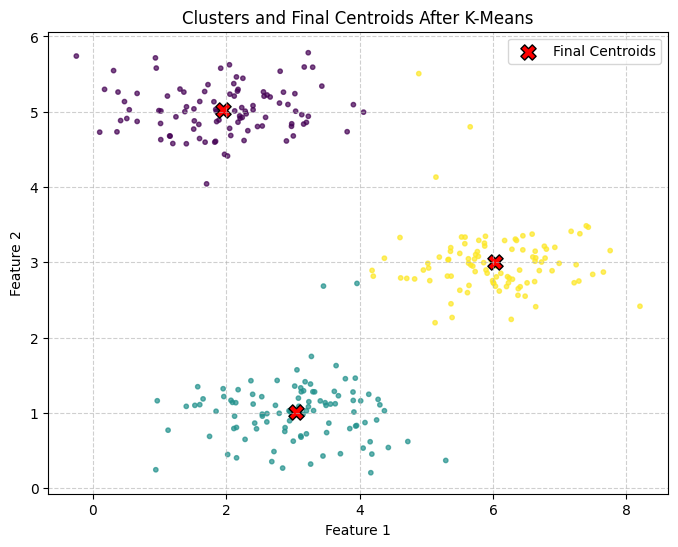

In [5]:
# TODO: implement
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None
    for it in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, K, rng)
        history.append(centroids.copy())
    return centroids, idx, history

# Example run
final_centroids, idx, hist = run_k_means(X, init_centroids, max_iters=10)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=idx, s=10, cmap='viridis', alpha=0.7)
plt.scatter(final_centroids[:,0], final_centroids[:,1], marker='X', s=120, color='red', edgecolors='black', label='Final Centroids')
plt.title('Clusters and Final Centroids After K-Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Task 5 - Initializing centroids
Implement `init_centroids(X, K, rng)` that picks K distinct random points from X.

Test by printing initial centroids for K = 3.

In [ ]:
# TODO: implement
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    # idx = ...
    # return X[idx].astype(float)
    raise NotImplementedError

# print(init_centroids(X, 3))

## Task 6 - Multiple initializations and evaluation
Define an inertia function `withinss(X, centroids, idx)` to compute the sum of squared distances to centroids.

- Run K-means for several random seeds
- Keep the run with lowest inertia
- Save a CSV report with x1, x2, cluster label

In [ ]:
# TODO: implement inertia and multi-start search
def withinss(X, centroids, idx):
    # diffs = ...
    # return float(np.sum(diffs * diffs))
    return None

# best = {'score': np.inf}
# for seed in range(5):
#     rng = np.random.default_rng(seed)
#     c0 = init_centroids(X, 3, rng)
#     cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
#     s = withinss(X, cF, idxF)
#     if s < best['score']:
#         best = {'score': s, 'centroids': cF, 'idx': idxF}
# print('Best inertia:', best['score'])

# import pandas as pd
# rep = pd.DataFrame({'x1': X[:,0], 'x2': X[:,1], 'cluster': best['idx']})
# rep.to_csv('kmeans_assignments.csv', index=False)
# print('Wrote kmeans_assignments.csv')